# Producto DW - Data Warehouse con PostgreSQL y Google Colab

**Objetivo:** implementar un Data Warehouse de ventas usando PostgreSQL dentro de Google Colab, Python, pandas, SQLAlchemy y Matplotlib.




## 1. Instalación de PostgreSQL en Google Colab
Ejecuta esta celda para instalar PostgreSQL dentro del entorno temporal de Colab.

In [1]:
# Instalación de PostgreSQL en Google Colab
!apt-get update -qq
!apt-get install -y postgresql postgresql-contrib > /dev/null
print("PostgreSQL instalado correctamente")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
PostgreSQL instalado correctamente


## 2. Inicio del servicio, contraseña y base de datos
Se inicia PostgreSQL, se configura la contraseña del usuario `postgres` y se crea la base `datawarehouse_tienda`.

In [2]:
# Iniciar el servicio de PostgreSQL
!service postgresql start

# Configurar contraseña del usuario postgres
!sudo -u postgres psql -c "ALTER USER postgres PASSWORD '123456';"

# Crear base de datos para la práctica
!sudo -u postgres psql -tc "SELECT 1 FROM pg_database WHERE datname = 'datawarehouse_tienda'" | grep -q 1 || sudo -u postgres createdb datawarehouse_tienda

print("Servicio iniciado y base de datos datawarehouse_tienda lista")

 * Starting PostgreSQL 14 database server
   ...done.
ALTER ROLE
Servicio iniciado y base de datos datawarehouse_tienda lista


## 3. Instalación e importación de librerías

In [3]:
# Librerías necesarias
!pip install -q pandas sqlalchemy psycopg2-binary matplotlib

import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text

print("Librerías instaladas e importadas correctamente")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 91.3 MB/s eta 0:00:00
Librerías instaladas e importadas correctamente


## 4. Conexión a PostgreSQL desde Python

In [4]:
# Datos de conexión
usuario = "postgres"
password = "123456"
host = "localhost"
puerto = "5432"
base_datos = "datawarehouse_tienda"

engine = create_engine(f"postgresql+psycopg2://{usuario}:{password}@{host}:{puerto}/{base_datos}")

# Prueba de conexión
with engine.connect() as conn:
    version = conn.execute(text("SELECT version();")).fetchone()[0]

print("Conexión correcta a PostgreSQL")
print(version)

Conexión correcta a PostgreSQL
PostgreSQL 14.23 (Ubuntu 14.23-0ubuntu0.22.04.1) on x86_64-pc-linux-gnu, compiled by gcc (Ubuntu 11.4.0-1ubuntu1~22.04.3) 11.4.0, 64-bit


## 5. Creación del modelo dimensional
Modelo tipo **estrella** con dimensiones de cliente, producto, región y tiempo, más la tabla de hechos `hecho_ventas`.

In [5]:
sql_creacion = """
DROP TABLE IF EXISTS hecho_ventas;
DROP TABLE IF EXISTS dim_cliente;
DROP TABLE IF EXISTS dim_producto;
DROP TABLE IF EXISTS dim_region;
DROP TABLE IF EXISTS dim_tiempo;

CREATE TABLE dim_cliente (
    id_cliente INTEGER PRIMARY KEY,
    nombre_cliente VARCHAR(100),
    segmento VARCHAR(50),
    edad INTEGER,
    estado VARCHAR(50)
);

CREATE TABLE dim_producto (
    id_producto INTEGER PRIMARY KEY,
    nombre_producto VARCHAR(100),
    categoria VARCHAR(50),
    marca VARCHAR(50),
    precio_unitario NUMERIC(10,2)
);

CREATE TABLE dim_region (
    id_region INTEGER PRIMARY KEY,
    region VARCHAR(50),
    ciudad VARCHAR(80),
    canal VARCHAR(50)
);

CREATE TABLE dim_tiempo (
    id_tiempo INTEGER PRIMARY KEY,
    fecha DATE,
    mes VARCHAR(20),
    mes_numero INTEGER,
    trimestre VARCHAR(5),
    anio INTEGER
);

CREATE TABLE hecho_ventas (
    id_venta INTEGER PRIMARY KEY,
    id_cliente INTEGER REFERENCES dim_cliente(id_cliente),
    id_producto INTEGER REFERENCES dim_producto(id_producto),
    id_region INTEGER REFERENCES dim_region(id_region),
    id_tiempo INTEGER REFERENCES dim_tiempo(id_tiempo),
    cantidad INTEGER,
    precio_unitario NUMERIC(10,2),
    descuento NUMERIC(10,2),
    total_venta NUMERIC(12,2)
);
"""

with engine.connect() as conn:
    conn.execute(text(sql_creacion))
    conn.commit()

print("Tablas del Data Warehouse creadas correctamente")

Tablas del Data Warehouse creadas correctamente


## 6. Simulación de datos
Estos datos representan clientes, productos, regiones/canales, fechas y ventas.

In [6]:
df_clientes = pd.DataFrame({
    "id_cliente": [1, 2, 3, 4, 5, 6],
    "nombre_cliente": ["Ana López", "Carlos Méndez", "María Torres", "Luis Hernández", "Sofía Ramírez", "Jorge Castillo"],
    "segmento": ["Estudiante", "Profesional", "Profesional", "Empresa", "Estudiante", "Empresa"],
    "edad": [21, 34, 29, 42, 23, 39],
    "estado": ["Veracruz", "Puebla", "CDMX", "Veracruz", "Oaxaca", "Puebla"]
})

df_productos = pd.DataFrame({
    "id_producto": [1, 2, 3, 4, 5, 6],
    "nombre_producto": ["Laptop Pro", "Mouse Inalámbrico", "Teclado Mecánico", "Monitor 24", "Impresora Eco", "Memoria USB"],
    "categoria": ["Computo", "Accesorios", "Accesorios", "Computo", "Oficina", "Almacenamiento"],
    "marca": ["Nova", "ClickMax", "KeyTech", "ViewPlus", "PrintGo", "DataFast"],
    "precio_unitario": [14500, 350, 1200, 3900, 4800, 180]
})

df_regiones = pd.DataFrame({
    "id_region": [1, 2, 3, 4],
    "region": ["Norte", "Centro", "Sur", "Golfo"],
    "ciudad": ["Monterrey", "CDMX", "Oaxaca", "Veracruz"],
    "canal": ["Tienda física", "Web", "App", "Distribuidor"]
})

df_tiempo = pd.DataFrame({
    "id_tiempo": [1, 2, 3, 4, 5, 6],
    "fecha": pd.to_datetime(["2026-01-10", "2026-02-15", "2026-03-05", "2026-04-18", "2026-05-23", "2026-06-07"]),
    "mes": ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio"],
    "mes_numero": [1, 2, 3, 4, 5, 6],
    "trimestre": ["T1", "T1", "T1", "T2", "T2", "T2"],
    "anio": [2026, 2026, 2026, 2026, 2026, 2026]
})

df_ventas = pd.DataFrame({
    "id_venta": list(range(1, 16)),
    "id_cliente": [1,2,3,4,5,6,1,2,3,4,5,6,1,3,5],
    "id_producto": [1,2,3,4,5,6,3,1,4,2,6,5,2,1,3],
    "id_region": [4,2,1,3,4,2,1,1,2,3,4,2,4,1,3],
    "id_tiempo": [1,1,2,2,3,3,4,4,5,5,6,6,1,3,5],
    "cantidad": [1,4,2,1,1,10,3,2,1,5,12,1,6,1,2],
    "descuento": [0,0,100,0,250,0,150,500,0,0,0,300,0,0,100]
})

# Calcular precio y total de venta a partir de producto y cantidad
df_ventas = df_ventas.merge(df_productos[["id_producto", "precio_unitario"]], on="id_producto", how="left")
df_ventas["total_venta"] = (df_ventas["cantidad"] * df_ventas["precio_unitario"]) - df_ventas["descuento"]

display(df_clientes)
display(df_productos)
display(df_regiones)
display(df_tiempo)
display(df_ventas)

,id_cliente,nombre_cliente,segmento,edad,estado
0,1,Ana López,Estudiante,21,Veracruz
1,2,Carlos Méndez,Profesional,34,Puebla
2,3,María Torres,Profesional,29,CDMX
3,4,Luis Hernández,Empresa,42,Veracruz
4,5,Sofía Ramírez,Estudiante,23,Oaxaca
5,6,Jorge Castillo,Empresa,39,Puebla


,id_producto,nombre_producto,categoria,marca,precio_unitario
0,1,Laptop Pro,Computo,Nova,14500
1,2,Mouse Inalámbrico,Accesorios,ClickMax,350
2,3,Teclado Mecánico,Accesorios,KeyTech,1200
3,4,Monitor 24,Computo,ViewPlus,3900
4,5,Impresora Eco,Oficina,PrintGo,4800
5,6,Memoria USB,Almacenamiento,DataFast,180


,id_region,region,ciudad,canal
0,1,Norte,Monterrey,Tienda física
1,2,Centro,CDMX,Web
2,3,Sur,Oaxaca,App
3,4,Golfo,Veracruz,Distribuidor


,id_tiempo,fecha,mes,mes_numero,trimestre,anio
0,1,2026-01-10,Enero,1,T1,2026
1,2,2026-02-15,Febrero,2,T1,2026
2,3,2026-03-05,Marzo,3,T1,2026
3,4,2026-04-18,Abril,4,T2,2026
4,5,2026-05-23,Mayo,5,T2,2026
5,6,2026-06-07,Junio,6,T2,2026


,id_venta,id_cliente,id_producto,id_region,id_tiempo,cantidad,descuento,precio_unitario,total_venta
0,1,1,1,4,1,1,0,14500,14500
1,2,2,2,2,1,4,0,350,1400
2,3,3,3,1,2,2,100,1200,2300
3,4,4,4,3,2,1,0,3900,3900
4,5,5,5,4,3,1,250,4800,4550
5,6,6,6,2,3,10,0,180,1800
6,7,1,3,1,4,3,150,1200,3450
7,8,2,1,1,4,2,500,14500,28500
8,9,3,4,2,5,1,0,3900,3900
9,10,4,2,3,5,5,0,350,1750


## 7. Exportación a CSV e importación como fuente de datos
Esto simula una fuente externa de datos que después será cargada al Data Warehouse.

In [7]:
# Exportar datos simulados a CSV
df_clientes.to_csv("clientes.csv", index=False)
df_productos.to_csv("productos.csv", index=False)
df_regiones.to_csv("regiones.csv", index=False)
df_tiempo.to_csv("tiempo.csv", index=False)
df_ventas.to_csv("ventas.csv", index=False)
print("Archivos CSV creados correctamente")

# Importar CSV
clientes_csv = pd.read_csv("clientes.csv")
productos_csv = pd.read_csv("productos.csv")
regiones_csv = pd.read_csv("regiones.csv")
tiempo_csv = pd.read_csv("tiempo.csv", parse_dates=["fecha"])
ventas_csv = pd.read_csv("ventas.csv")
print("CSV importados correctamente")

display(ventas_csv.head())

Archivos CSV creados correctamente
CSV importados correctamente


,id_venta,id_cliente,id_producto,id_region,id_tiempo,cantidad,descuento,precio_unitario,total_venta
0,1,1,1,4,1,1,0,14500,14500
1,2,2,2,2,1,4,0,350,1400
2,3,3,3,1,2,2,100,1200,2300
3,4,4,4,3,2,1,0,3900,3900
4,5,5,5,4,3,1,250,4800,4550


## 8. Normalización y validación de calidad de datos

In [8]:
# Función para revisar nulos y duplicados
def revisar_calidad(nombre, df):
    print(f"\n--- {nombre} ---")
    print("Filas:", len(df))
    print("Nulos por columna:")
    print(df.isnull().sum())
    print("Duplicados:", df.duplicated().sum())

for nombre, df in {
    "clientes": clientes_csv,
    "productos": productos_csv,
    "regiones": regiones_csv,
    "tiempo": tiempo_csv,
    "ventas": ventas_csv
}.items():
    revisar_calidad(nombre, df)

# Eliminar duplicados si existieran
clientes_csv = clientes_csv.drop_duplicates()
productos_csv = productos_csv.drop_duplicates()
regiones_csv = regiones_csv.drop_duplicates()
tiempo_csv = tiempo_csv.drop_duplicates()
ventas_csv = ventas_csv.drop_duplicates()

# Asegurar tipos de datos principales
tiempo_csv["fecha"] = pd.to_datetime(tiempo_csv["fecha"])
ventas_csv["total_venta"] = ventas_csv["total_venta"].astype(float)
ventas_csv["precio_unitario"] = ventas_csv["precio_unitario"].astype(float)

print("Datos normalizados y validados correctamente")
ventas_csv.info()


--- clientes ---
Filas: 6
Nulos por columna:
id_cliente        0
nombre_cliente    0
segmento          0
edad              0
estado            0
dtype: int64
Duplicados: 0

--- productos ---
Filas: 6
Nulos por columna:
id_producto        0
nombre_producto    0
categoria          0
marca              0
precio_unitario    0
dtype: int64
Duplicados: 0

--- regiones ---
Filas: 4
Nulos por columna:
id_region    0
region       0
ciudad       0
canal        0
dtype: int64
Duplicados: 0

--- tiempo ---
Filas: 6
Nulos por columna:
id_tiempo     0
fecha         0
mes           0
mes_numero    0
trimestre     0
anio          0
dtype: int64
Duplicados: 0

--- ventas ---
Filas: 15
Nulos por columna:
id_venta           0
id_cliente         0
id_producto        0
id_region          0
id_tiempo          0
cantidad           0
descuento          0
precio_unitario    0
total_venta        0
dtype: int64
Duplicados: 0
Datos normalizados y validados correctamente
<class 'pandas.core.frame.DataFrame'>
Rang

## 9. Carga de datos al Data Warehouse en PostgreSQL

In [9]:
# Limpiar tablas antes de cargar para evitar duplicados
with engine.connect() as conn:
    conn.execute(text("DELETE FROM hecho_ventas;"))
    conn.execute(text("DELETE FROM dim_cliente;"))
    conn.execute(text("DELETE FROM dim_producto;"))
    conn.execute(text("DELETE FROM dim_region;"))
    conn.execute(text("DELETE FROM dim_tiempo;"))
    conn.commit()

# Cargar primero dimensiones y después hechos
clientes_csv.to_sql("dim_cliente", engine, if_exists="append", index=False)
productos_csv.to_sql("dim_producto", engine, if_exists="append", index=False)
regiones_csv.to_sql("dim_region", engine, if_exists="append", index=False)
tiempo_csv.to_sql("dim_tiempo", engine, if_exists="append", index=False)
ventas_csv.to_sql("hecho_ventas", engine, if_exists="append", index=False)

print("Datos cargados correctamente al Data Warehouse")

Datos cargados correctamente al Data Warehouse


## 10. Validación de tablas y conteos

In [10]:
consulta_conteos = """
SELECT 'dim_cliente' AS tabla, COUNT(*) AS registros FROM dim_cliente
UNION ALL SELECT 'dim_producto', COUNT(*) FROM dim_producto
UNION ALL SELECT 'dim_region', COUNT(*) FROM dim_region
UNION ALL SELECT 'dim_tiempo', COUNT(*) FROM dim_tiempo
UNION ALL SELECT 'hecho_ventas', COUNT(*) FROM hecho_ventas;
"""
conteos = pd.read_sql(consulta_conteos, engine)
display(conteos)

,tabla,registros
0,dim_cliente,6
1,dim_producto,6
2,dim_region,4
3,dim_tiempo,6
4,hecho_ventas,15


## 11. Consulta general del Data Warehouse
Se unen dimensiones y tabla de hechos para obtener un reporte de ventas completo.

In [11]:
consulta_general = """
SELECT
    v.id_venta,
    c.nombre_cliente,
    c.segmento,
    p.nombre_producto,
    p.categoria,
    r.region,
    r.ciudad,
    r.canal,
    t.fecha,
    t.mes,
    t.trimestre,
    v.cantidad,
    v.precio_unitario,
    v.descuento,
    v.total_venta
FROM hecho_ventas v
INNER JOIN dim_cliente c ON v.id_cliente = c.id_cliente
INNER JOIN dim_producto p ON v.id_producto = p.id_producto
INNER JOIN dim_region r ON v.id_region = r.id_region
INNER JOIN dim_tiempo t ON v.id_tiempo = t.id_tiempo
ORDER BY v.id_venta;
"""
reporte_general = pd.read_sql(consulta_general, engine)
display(reporte_general)

,id_venta,nombre_cliente,segmento,nombre_producto,categoria,region,ciudad,canal,fecha,mes,trimestre,cantidad,precio_unitario,descuento,total_venta
0,1,Ana López,Estudiante,Laptop Pro,Computo,Golfo,Veracruz,Distribuidor,2026-01-10,Enero,T1,1,14500.0,0.0,14500.0
1,2,Carlos Méndez,Profesional,Mouse Inalámbrico,Accesorios,Centro,CDMX,Web,2026-01-10,Enero,T1,4,350.0,0.0,1400.0
2,3,María Torres,Profesional,Teclado Mecánico,Accesorios,Norte,Monterrey,Tienda física,2026-02-15,Febrero,T1,2,1200.0,100.0,2300.0
3,4,Luis Hernández,Empresa,Monitor 24,Computo,Sur,Oaxaca,App,2026-02-15,Febrero,T1,1,3900.0,0.0,3900.0
4,5,Sofía Ramírez,Estudiante,Impresora Eco,Oficina,Golfo,Veracruz,Distribuidor,2026-03-05,Marzo,T1,1,4800.0,250.0,4550.0
5,6,Jorge Castillo,Empresa,Memoria USB,Almacenamiento,Centro,CDMX,Web,2026-03-05,Marzo,T1,10,180.0,0.0,1800.0
6,7,Ana López,Estudiante,Teclado Mecánico,Accesorios,Norte,Monterrey,Tienda física,2026-04-18,Abril,T2,3,1200.0,150.0,3450.0
7,8,Carlos Méndez,Profesional,Laptop Pro,Computo,Norte,Monterrey,Tienda física,2026-04-18,Abril,T2,2,14500.0,500.0,28500.0
8,9,María Torres,Profesional,Monitor 24,Computo,Centro,CDMX,Web,2026-05-23,Mayo,T2,1,3900.0,0.0,3900.0
9,10,Luis Hernández,Empresa,Mouse Inalámbrico,Accesorios,Sur,Oaxaca,App,2026-05-23,Mayo,T2,5,350.0,0.0,1750.0


## 12. Indicador 1: Ventas por región

,region,total_ventas
0,Norte,48750.0
1,Golfo,23310.0
2,Centro,11600.0
3,Sur,7950.0


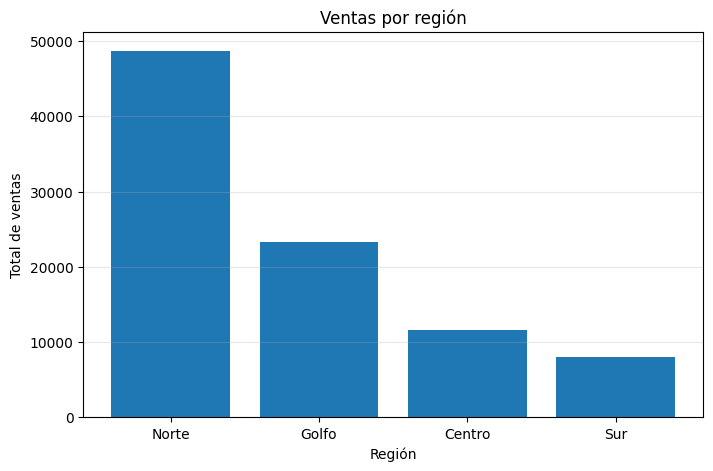

In [12]:
ventas_region = pd.read_sql("""
SELECT
    r.region,
    SUM(v.total_venta) AS total_ventas
FROM hecho_ventas v
INNER JOIN dim_region r ON v.id_region = r.id_region
GROUP BY r.region
ORDER BY total_ventas DESC;
""", engine)

display(ventas_region)

plt.figure(figsize=(8,5))
plt.bar(ventas_region["region"], ventas_region["total_ventas"])
plt.title("Ventas por región")
plt.xlabel("Región")
plt.ylabel("Total de ventas")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

## 13. Indicador 2: Productos más vendidos

,nombre_producto,categoria,cantidad_vendida,total_ventas
0,Memoria USB,Almacenamiento,22,3960.0
1,Mouse Inalámbrico,Accesorios,15,5250.0
2,Teclado Mecánico,Accesorios,7,8050.0
3,Laptop Pro,Computo,4,57500.0
4,Monitor 24,Computo,2,7800.0
5,Impresora Eco,Oficina,2,9050.0


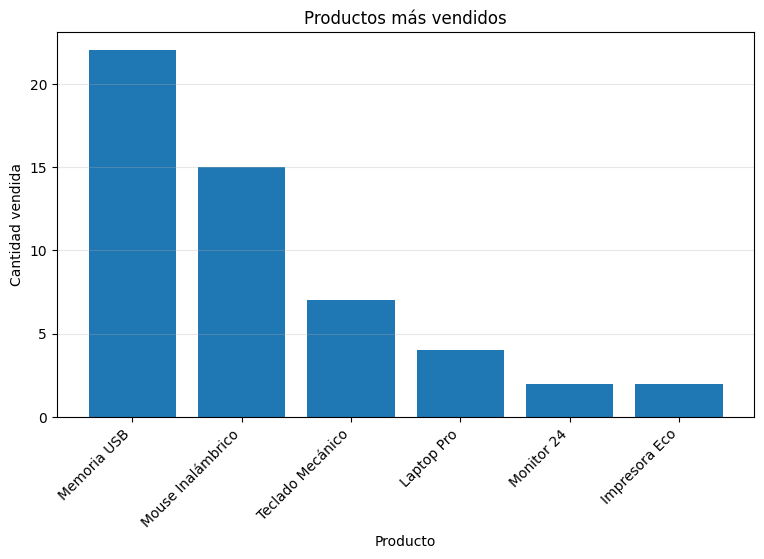

In [13]:
productos_vendidos = pd.read_sql("""
SELECT
    p.nombre_producto,
    p.categoria,
    SUM(v.cantidad) AS cantidad_vendida,
    SUM(v.total_venta) AS total_ventas
FROM hecho_ventas v
INNER JOIN dim_producto p ON v.id_producto = p.id_producto
GROUP BY p.nombre_producto, p.categoria
ORDER BY cantidad_vendida DESC;
""", engine)

display(productos_vendidos)

plt.figure(figsize=(9,5))
plt.bar(productos_vendidos["nombre_producto"], productos_vendidos["cantidad_vendida"])
plt.title("Productos más vendidos")
plt.xlabel("Producto")
plt.ylabel("Cantidad vendida")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 14. Indicador 3: Ventas por mes

,anio,mes_numero,mes,total_ventas
0,2026,1,Enero,18000.0
1,2026,2,Febrero,6200.0
2,2026,3,Marzo,20850.0
3,2026,4,Abril,31950.0
4,2026,5,Mayo,7950.0
5,2026,6,Junio,6660.0


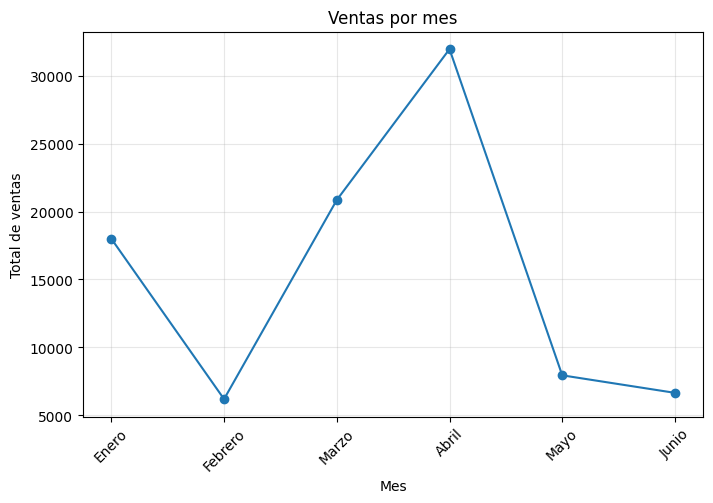

In [14]:
ventas_mes = pd.read_sql("""
SELECT
    t.anio,
    t.mes_numero,
    t.mes,
    SUM(v.total_venta) AS total_ventas
FROM hecho_ventas v
INNER JOIN dim_tiempo t ON v.id_tiempo = t.id_tiempo
GROUP BY t.anio, t.mes_numero, t.mes
ORDER BY t.anio, t.mes_numero;
""", engine)

display(ventas_mes)

plt.figure(figsize=(8,5))
plt.plot(ventas_mes["mes"], ventas_mes["total_ventas"], marker="o")
plt.title("Ventas por mes")
plt.xlabel("Mes")
plt.ylabel("Total de ventas")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

## 15. Indicador adicional: Ventas por canal y ticket promedio

,canal,numero_ventas,total_ventas,ticket_promedio
0,Tienda física,4,48750.0,12187.5
1,Distribuidor,4,23310.0,5827.5
2,Web,4,11600.0,2900.0
3,App,3,7950.0,2650.0


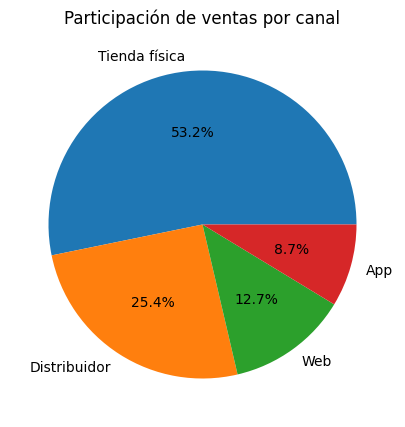

In [15]:
ventas_canal = pd.read_sql("""
SELECT
    r.canal,
    COUNT(v.id_venta) AS numero_ventas,
    SUM(v.total_venta) AS total_ventas,
    AVG(v.total_venta) AS ticket_promedio
FROM hecho_ventas v
INNER JOIN dim_region r ON v.id_region = r.id_region
GROUP BY r.canal
ORDER BY total_ventas DESC;
""", engine)

display(ventas_canal)

plt.figure(figsize=(8,5))
plt.pie(ventas_canal["total_ventas"], labels=ventas_canal["canal"], autopct="%1.1f%%")
plt.title("Participación de ventas por canal")
plt.show()

## 16. Respaldo de la base de datos (opcional)
Este comando genera un respaldo SQL del Data Warehouse para entregarlo como evidencia adicional.

In [16]:
# Respaldo opcional de la base de datos
!PGPASSWORD=123456 pg_dump -U postgres -h localhost datawarehouse_tienda > respaldo_datawarehouse_tienda.sql
print("Respaldo generado: respaldo_datawarehouse_tienda.sql")

Respaldo generado: respaldo_datawarehouse_tienda.sql
